# NB01 — Data Audit

**Purpose**: Understand the data before writing any model code.  
This notebook contains no ML. It verifies data integrity, visualises the BT score
distribution, checks that every labelled intersection has a photo on disk, and proposes
a reproducible train/val split.

**Inputs**: `data/processed/bt_scores_augmented.csv` (produced by NB00)

**Outputs**:
- `outputs/split_assignment.csv` — one row per sample, with `cv_split` label
- Various diagnostic figures (inline)

---

**Imports** — Load the libraries used throughout this notebook.

In [14]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split

# geopandas is used for spatial plots; fail gracefully if not installed
try:
    import geopandas as gpd
    HAS_GEOPANDAS = True
except ImportError:
    warnings.warn("geopandas not available — spatial plot will be skipped")
    HAS_GEOPANDAS = False

**Configuration** — All file paths and hyperparameters are defined here as named constants. Change values in this cell only; never hardcode paths further down.

In [15]:
# ---------------------------------------------------------------------------
# CONFIGURATION — all paths and constants defined here, never inside functions
# ---------------------------------------------------------------------------

# Root of the cv/ folder (this notebook lives in cv/pipeline/, so cv/ is one level up)
CV_ROOT = Path("..")

# Reprojected photos: REPRO_ROOT / {intersection_id} / leg_{bearing:.0f}.jpeg
REPRO_ROOT = Path(r"D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_new")

# Input CSVs
# bt_scores_augmented.csv is produced by NB00; when USE_AUGMENTATION=False it is
# identical to bt_scores.csv (passthrough), so this path is always valid.
BT_SCORES_CSV = CV_ROOT / "data" / "processed" / "bt_scores_augmented.csv"
LEGS_CSV      = CV_ROOT / "data" / "raw" / "sampled_legs_directional_clean.csv"

# GeoPackage with all Rotterdam intersections (stratified)
INTERSECTIONS_GPKG = CV_ROOT.parent / "intersections" / "data" / "processed" / "intersections_stratified.gpkg"

# Outputs
OUTPUTS_DIR = CV_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)
SPLIT_CSV = OUTPUTS_DIR / "split_assignment.csv"

# Train/val ratio and random seed (fixed for reproducibility)
VAL_FRACTION = 0.2
RANDOM_SEED  = 42

print(f"BT scores path : {BT_SCORES_CSV}  (exists={BT_SCORES_CSV.exists()})")
print(f"Legs CSV path  : {LEGS_CSV}  (exists={LEGS_CSV.exists()})")
print(f"GPKG path      : {INTERSECTIONS_GPKG}  (exists={INTERSECTIONS_GPKG.exists()})")
print(f"REPRO_ROOT     : {REPRO_ROOT}  (exists={REPRO_ROOT.exists()})")

BT scores path : ..\data\processed\bt_scores_augmented.csv  (exists=True)
Legs CSV path  : ..\data\raw\sampled_legs_directional_clean.csv  (exists=True)
GPKG path      : intersections\data\processed\intersections_stratified.gpkg  (exists=False)
REPRO_ROOT     : D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_new  (exists=True)


## 1. Load data

Load both source files and print their shapes and column names to confirm nothing unexpected changed upstream.

In [16]:
# Load the augmented BT scores (original + synthetic copies from NB00)
bt = pd.read_csv(BT_SCORES_CSV)

# Load the full set of sampled legs (all 308 intersections in the survey design)
legs = pd.read_csv(LEGS_CSV)

print("=== bt_scores_augmented.csv ===")
print(f"  Shape   : {bt.shape}")
print(f"  Columns : {list(bt.columns)}")
if "is_augmented" in bt.columns:
    print(f"  Originals / augmented : {(~bt['is_augmented']).sum()} / {bt['is_augmented'].sum()}")
print()
print("=== sampled_legs_directional_clean.csv ===")
print(f"  Shape   : {legs.shape}")
print(f"  Columns : {list(legs.columns)}")

=== bt_scores_augmented.csv ===
  Shape   : (425, 15)
  Columns : ['intersection_id', 'bt_param_raw', 'bt_score', 'n_comparisons', 'n_wins', 'image_path', 'leg_bearing', 'dim_type', 'dim_risk', 'dim_priority', 'dim_speed', 'is_centrum', 'is_augmented', 'aug_seed', 'sample_id']
  Originals / augmented : 85 / 340

=== sampled_legs_directional_clean.csv ===
  Shape   : (308, 30)
  Columns : ['intersection_id', 'leg_bearing', 'photo_filename', 'photo_dist_m', 'u_deg', 'photo_x', 'photo_y', 'photo_bearing_to_inter', 'candidate_rank', 'is_panorama', 'selected_direction', 'photo_filepath', 'filepath_front', 'filepath_right', 'filepath_back', 'filepath_left', 'requires_stitch', 'stitch_left_filepath', 'stitch_right_filepath', 'stitch_inter_col_frac', 'neighbor_jte_id', 'WVK_ID', 'intensity_wvk', 'dim_type', 'dim_risk', 'dim_priority', 'dim_speed', 'is_centrum', 'direction_patched', 'quality_patched']


Check dtypes and null counts for the key columns. Missing values in stratum columns (`dim_type`, `is_centrum`) will affect the split stratification later.

In [17]:
# Report dtypes and missing values for bt_scores (originals only to avoid duplication)
originals = bt[bt["is_augmented"] == False] if "is_augmented" in bt.columns else bt

print("=== bt_scores — dtypes and nulls (originals only) ===")
audit_bt = pd.DataFrame({
    "dtype"  : originals.dtypes,
    "n_null" : originals.isna().sum(),
    "pct_null": (originals.isna().mean() * 100).round(1),
    "n_unique": originals.nunique(),
})
print(audit_bt.to_string())
print()

# Report key columns from legs
print("=== sampled_legs — dtypes and nulls ===")
key_leg_cols = ["intersection_id", "leg_bearing", "photo_filepath",
                "dim_type", "dim_risk", "dim_priority", "dim_speed", "is_centrum"]
audit_legs = pd.DataFrame({
    "dtype"  : legs[key_leg_cols].dtypes,
    "n_null" : legs[key_leg_cols].isna().sum(),
    "n_unique": legs[key_leg_cols].nunique(),
})
print(audit_legs.to_string())

=== bt_scores — dtypes and nulls (originals only) ===
                   dtype  n_null  pct_null  n_unique
intersection_id    int64       0       0.0        85
bt_param_raw     float64       0       0.0        81
bt_score         float64       0       0.0        80
n_comparisons      int64       0       0.0        21
n_wins             int64       0       0.0        15
image_path           str       0       0.0        85
leg_bearing      float64       5       5.9        76
dim_type             str       5       5.9         2
dim_risk             str       5       5.9         1
dim_priority         str       5       5.9         3
dim_speed            str       5       5.9         1
is_centrum        object       5       5.9         2
is_augmented        bool       0       0.0         1
aug_seed           int64       0       0.0         1
sample_id            str       0       0.0        85

=== sampled_legs — dtypes and nulls ===
                   dtype  n_null  n_unique
intersection_i

Descriptive statistics for `bt_score`. Skewness and kurtosis indicate whether the score distribution deviates from normal — relevant for regression assumptions in later models.

In [18]:
# Compute stats on originals only so augmented label noise does not distort the picture
print("=== bt_score descriptive statistics (originals only) ===")
print(originals["bt_score"].describe().round(4))

sk = stats.skew(originals["bt_score"].dropna())
ku = stats.kurtosis(originals["bt_score"].dropna())
print(f"\nSkewness : {sk:.3f}  (>0 = right tail, <0 = left tail)")
print(f"Kurtosis : {ku:.3f}  (excess; >0 heavier tails than normal)")

=== bt_score descriptive statistics (originals only) ===
count    85.0000
mean      0.6649
std       0.2224
min       0.0000
25%       0.5114
50%       0.6951
75%       0.8302
max       1.0000
Name: bt_score, dtype: float64

Skewness : -0.754  (>0 = right tail, <0 = left tail)
Kurtosis : 0.276  (excess; >0 heavier tails than normal)


## 2. BT score distribution

Plot the score distribution and the number of comparisons per intersection. Few comparisons mean less reliable labels — useful to know before interpreting residuals in NB02/03.

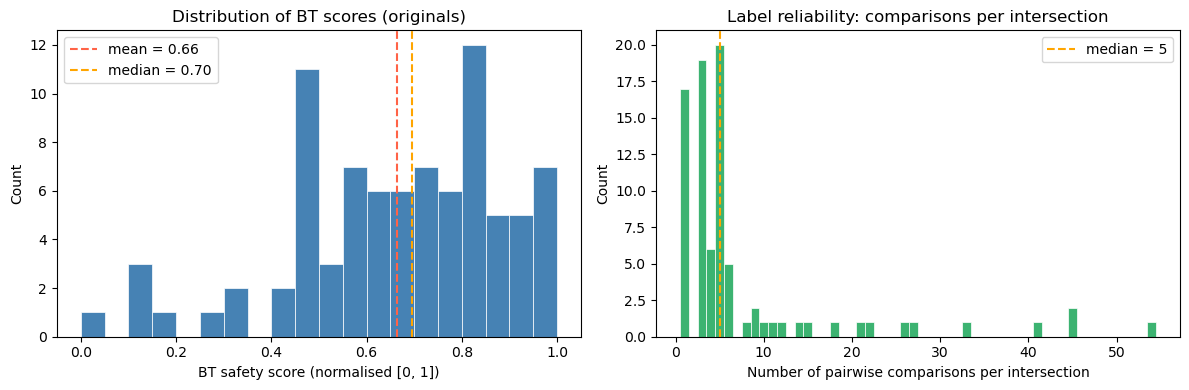

Floor effect (score < 0.10): 1 intersections (1.2%)
Ceiling effect (score > 0.90): 12 intersections (14.1%)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: histogram of bt_score (originals only) ---
ax = axes[0]
ax.hist(originals["bt_score"], bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(originals["bt_score"].mean(), color="tomato", linestyle="--",
           label=f"mean = {originals['bt_score'].mean():.2f}")
ax.axvline(originals["bt_score"].median(), color="orange", linestyle="--",
           label=f"median = {originals['bt_score'].median():.2f}")
ax.set_xlabel("BT safety score (normalised [0, 1])")
ax.set_ylabel("Count")
ax.set_title("Distribution of BT scores (originals)")
ax.legend()

# --- Right: n_comparisons per intersection to show label reliability ---
ax2 = axes[1]
ax2.hist(originals["n_comparisons"], bins=range(1, originals["n_comparisons"].max() + 2),
         color="mediumseagreen", edgecolor="white", linewidth=0.5, align="left")
ax2.set_xlabel("Number of pairwise comparisons per intersection")
ax2.set_ylabel("Count")
ax2.set_title("Label reliability: comparisons per intersection")
ax2.axvline(originals["n_comparisons"].median(), color="orange", linestyle="--",
            label=f"median = {originals['n_comparisons'].median():.0f}")
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb01_bt_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

floor_n = (originals["bt_score"] < 0.1).sum()
ceil_n  = (originals["bt_score"] > 0.9).sum()
print(f"Floor effect (score < 0.10): {floor_n} intersections ({floor_n/len(originals)*100:.1f}%)")
print(f"Ceiling effect (score > 0.90): {ceil_n} intersections ({ceil_n/len(originals)*100:.1f}%)")

## 3. Photo verification

For each labelled intersection in `bt_scores_augmented.csv`, check whether the
corresponding reprojected JPEG exists at
`REPRO_ROOT / {intersection_id} / leg_{bearing:.0f}.jpeg`.
Checked on originals only — augmented copies reference the same photo.

Join `leg_bearing` from the legs CSV onto the BT scores. The bearing is needed to construct the expected photo path (`leg_{bearing:.0f}.jpeg`). Intersections absent from the legs CSV will have no bearing and cannot be checked.

In [20]:
# Check photos for original rows only — augmented copies point to the same file
bt_with_bearing = originals.merge(
    legs[["intersection_id", "leg_bearing"]],
    on="intersection_id",
    how="left",
    suffixes=("", "_legs"),
)

# If leg_bearing was already in bt (carried over from legs join in sync_inputs),
# the merge above creates a duplicate — use the one from legs directly
if "leg_bearing" in originals.columns:
    bt_with_bearing = originals.copy()

print("Rows with leg_bearing available:",
      bt_with_bearing["leg_bearing"].notna().sum(), "/", len(bt_with_bearing))

Rows with leg_bearing available: 80 / 85


For each labelled intersection, construct the expected JPEG path and test whether it exists. Prints a `found / missing / no_bearing` summary and lists any missing paths for manual inspection.

In [21]:
def repro_photo_path(intersection_id: int, bearing: float) -> Path:
    """Construct the expected reprojected photo path for a given intersection leg."""
    return REPRO_ROOT / str(intersection_id) / f"leg_{bearing:.0f}.jpeg"


results = []
for _, row in bt_with_bearing.iterrows():
    iid     = row["intersection_id"]
    bearing = row.get("leg_bearing", np.nan)

    if pd.isna(bearing):
        results.append({"intersection_id": iid, "status": "no_bearing", "photo_path": None})
        continue

    path   = repro_photo_path(iid, bearing)
    status = "found" if path.exists() else "missing"
    results.append({"intersection_id": iid, "status": status, "photo_path": str(path)})

photo_check = pd.DataFrame(results)

print("=== Photo existence check ===")
for status, n in photo_check["status"].value_counts().items():
    print(f"  {status:12s}: {n:3d}  ({n/len(photo_check)*100:.1f}%)")
print(f"  {'TOTAL':12s}: {len(photo_check):3d}")

missing = photo_check[photo_check["status"] == "missing"]
if not missing.empty:
    print(f"\nMissing photos ({len(missing)}):")
    for _, row in missing.iterrows():
        print(f"  {row['intersection_id']}  →  {row['photo_path']}")

no_bearing = photo_check[photo_check["status"] == "no_bearing"]
if not no_bearing.empty:
    print(f"\nNo bearing data ({len(no_bearing)}) — not in sampled_legs:")
    print(no_bearing["intersection_id"].tolist())

=== Photo existence check ===
  found       :  79  (92.9%)
  no_bearing  :   5  (5.9%)
  missing     :   1  (1.2%)
  TOTAL       :  85

Missing photos (1):
  185273145  →  D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_new\185273145\leg_217.jpeg

No bearing data (5) — not in sampled_legs:
[189276040, 600111024, 190266032, 184273072, 600485593]


## 4. Geographic distribution

Plot all Rotterdam intersections as a grey background, then overlay the labelled subset coloured by BT score. Shows whether the labelled sample covers the city spatially or is clustered in one area.

In [22]:
if not HAS_GEOPANDAS:
    print("Skipping geographic plot — geopandas not available.")
elif not INTERSECTIONS_GPKG.exists():
    print(f"Skipping geographic plot — GPKG not found at {INTERSECTIONS_GPKG}")
else:
    gdf_all = gpd.read_file(INTERSECTIONS_GPKG)
    print(f"All intersections: {len(gdf_all)} rows, CRS={gdf_all.crs}")

    labelled_ids = set(originals["intersection_id"])
    gdf_all["labelled"] = gdf_all["intersection_id"].isin(labelled_ids)

    # Reproject to RD New (EPSG:28992) for display if needed
    gdf_plot = gdf_all.to_crs(epsg=28992) if gdf_all.crs and gdf_all.crs.to_epsg() != 28992 else gdf_all

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf_plot[~gdf_plot["labelled"]].plot(
        ax=ax, color="lightgray", markersize=4, label=f"Unlabelled ({(~gdf_all['labelled']).sum()})"
    )

    labelled_gdf = gdf_plot[gdf_plot["labelled"]].merge(
        originals[["intersection_id", "bt_score"]], on="intersection_id", how="left"
    )
    labelled_gdf.plot(
        ax=ax, column="bt_score", cmap="RdYlGn", markersize=40, legend=False,
        label=f"Labelled ({gdf_all['labelled'].sum()})"
    )

    sm = plt.cm.ScalarMappable(cmap="RdYlGn",
                                norm=plt.Normalize(vmin=labelled_gdf["bt_score"].min(),
                                                   vmax=labelled_gdf["bt_score"].max()))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02).set_label("BT safety score")

    ax.set_title("Labelled intersections overlaid on Rotterdam network", fontsize=13)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "nb01_geographic_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Geographic plot saved.")

Skipping geographic plot — GPKG not found at intersections\data\processed\intersections_stratified.gpkg


## 5. Train / validation split

Split is decided on **original** rows only (no augmented copies), stratified by
`dim_type` × `is_centrum`.  

After the split, augmented copies follow their original:
- Augmented copies of **train** intersections → `train`
- Augmented copies of **val** intersections → `excluded` (prevents leakage; val stays clean)
- Intersections in `sampled_legs` without a BT score → `unlabelled`

Build a stratification key from `dim_type` × `is_centrum` using originals only. Strata with fewer than 2 members are merged into the largest stratum — collapsing to a new `"other"` group would just create another group with 1 member.

In [23]:
# Work on originals only — the split boundary is defined at the intersection level
strat_df = originals[["intersection_id", "dim_type", "is_centrum"]].copy()
strat_df["dim_type"]   = strat_df["dim_type"].fillna("unknown")
strat_df["is_centrum"] = strat_df["is_centrum"].fillna(False).astype(str)
strat_df["strat_key"]  = strat_df["dim_type"].str.strip() + "_" + strat_df["is_centrum"]

key_counts = strat_df["strat_key"].value_counts()
print("Stratum key distribution (originals only):")
print(key_counts.to_string())

# Merge rare strata (< 2 members) into the majority class so train_test_split
# does not fail. Collapsing to a new "other" group would just create another
# under-populated group — merging into the majority guarantees it stays >= 2.
rare_keys    = key_counts[key_counts < 2].index
majority_key = key_counts.index[0]
strat_df.loc[strat_df["strat_key"].isin(rare_keys), "strat_key"] = majority_key
print(f"\nRare strata merged into '{majority_key}': {list(rare_keys)}")

Stratum key distribution (originals only):
strat_key
4+_False         43
T_False          23
4+_True          13
unknown_False     5
T_True            1

Rare strata merged into '4+_False': ['T_True']


Perform the 80/20 split on `intersection_id` — always split on ID explicitly, not on file paths, so the intent is clear and robust if the input data changes.

In [24]:
train_ids, val_ids = train_test_split(
    strat_df["intersection_id"].values,
    test_size=VAL_FRACTION,
    random_state=RANDOM_SEED,
    stratify=strat_df["strat_key"].values,
)

train_set = set(train_ids)
val_set   = set(val_ids)

print(f"Train: {len(train_ids)} intersections  ({len(train_ids)/len(strat_df)*100:.1f}%)")
print(f"Val  : {len(val_ids)} intersections  ({len(val_ids)/len(strat_df)*100:.1f}%)")

Train: 68 intersections  (80.0%)
Val  : 17 intersections  (20.0%)


Assign every sample (original + augmented + unlabelled) its `cv_split` label and save to disk.

In [25]:
def assign_split(row):
    """Return cv_split label for a single row of the augmented BT dataset."""
    iid          = row["intersection_id"]
    is_augmented = row.get("is_augmented", False)
    if iid in train_set:
        return "train"                              # originals and augmented copies
    elif iid in val_set:
        return "excluded" if is_augmented else "val" # augmented val copies not used
    else:
        return "unlabelled"

# Apply to the full augmented dataset
split_df = bt.copy()
split_df["cv_split"] = split_df.apply(assign_split, axis=1)

# Append unlabelled intersections from sampled_legs that have no BT score
labelled_set = set(bt["intersection_id"])
unlabelled_ids = [i for i in legs["intersection_id"].unique() if i not in labelled_set]
unlabelled_df = pd.DataFrame({
    "intersection_id": unlabelled_ids,
    "is_augmented"   : False,
    "sample_id"      : [f"{i}_orig" for i in unlabelled_ids],
    "cv_split"       : "unlabelled",
})
split_df = pd.concat([split_df, unlabelled_df], ignore_index=True)

print("Split assignment summary:")
print(split_df["cv_split"].value_counts().to_string())
print()

# Sanity check: val must contain only clean originals
val_rows = split_df[split_df["cv_split"] == "val"]
assert val_rows["is_augmented"].sum() == 0, "Val set contains augmented samples — leakage!"
print("Assertion passed: val set contains only original samples.")

split_df[["sample_id", "intersection_id", "is_augmented", "aug_seed", "cv_split"]].to_csv(
    SPLIT_CSV, index=False
)
print(f"Saved split assignment to: {SPLIT_CSV}")

Split assignment summary:
cv_split
train         340
unlabelled    228
excluded       68
val            17

Assertion passed: val set contains only original samples.
Saved split assignment to: ..\outputs\split_assignment.csv


Visualise the BT score distribution for train vs val side by side. If the means diverge notably, the stratification did not balance well — consider adjusting the strata or the seed.

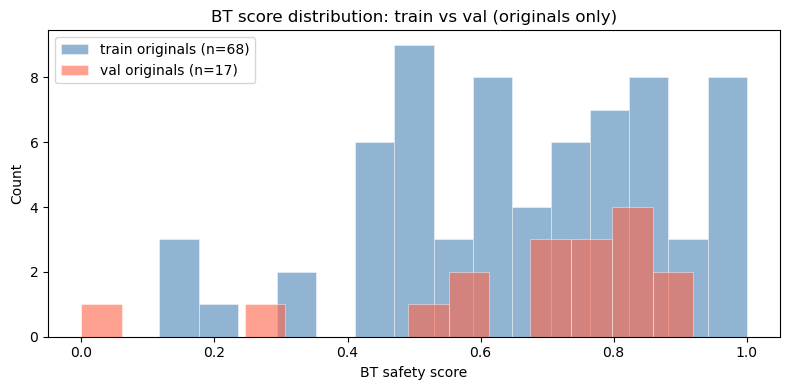

           mean    std    min   max
cv_split                           
train     0.663  0.220  0.117  1.00
val       0.672  0.239  0.000  0.92


In [26]:
# Use originals only so augmented label noise does not distort the comparison
originals_with_split = split_df[
    (split_df["is_augmented"] == False) & (split_df["cv_split"].isin(["train", "val"]))
].copy()

fig, ax = plt.subplots(figsize=(8, 4))
for split_label, colour in [("train", "steelblue"), ("val", "tomato")]:
    subset = originals_with_split[originals_with_split["cv_split"] == split_label]["bt_score"]
    ax.hist(subset, bins=15, alpha=0.6, color=colour, edgecolor="white",
            linewidth=0.5, label=f"{split_label} originals (n={len(subset)})")

ax.set_xlabel("BT safety score")
ax.set_ylabel("Count")
ax.set_title("BT score distribution: train vs val (originals only)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb01_split_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(originals_with_split.groupby("cv_split")["bt_score"].agg(["mean", "std", "min", "max"]).round(3))

## Summary

- **Labelled intersections**: 68 originals (test data; full survey not yet complete)
- **Score distribution**: *[note skewness, ceiling/floor effects from cell output above]*
- **Photo check**: *[fill in from cell output: N found, N missing, N no_bearing]*
- **Split**: 80/20 stratified by dim_type × is_centrum on originals; augmented copies follow their original into train
- **Saved**: `outputs/split_assignment.csv`

**Decision to proceed**: If all (or nearly all) labelled intersections have a photo on
disk, proceed to NB02. If more than ~10% are missing, investigate the REPRO_ROOT path
before continuing.